In [38]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from app.utils.gpt_parser import canonical_portfolio
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from app.core.calculations.returns.calculator import ReturnsCalculator, PortfolioReturnsCalculator
from app.core.calculations.performance.calculator import PerformanceCalculator
from app.core.calculations.risk.calculator import RiskCalculator
from app.repositories.price_data import get_price_data_daily, get_dividends_series
from app.repositories.price_data import fetch_bulk_price_data_for_tickers
import matplotlib.pyplot as plt
# Fetch industry and sub-industry data for all tickers
from app.db.core.db_config import MarketSession, ProphitAltsSession
from app.db.core.market_data_models import Ticker
from app.db.core.prophit_alts_models import FundFinalPosition
from app.utils.serialize_output import serialize_sqlalchemy_obj



In [39]:


portfolio = [
  {
    "ticker": "CCEP",
    "position": "long",
    "thesis": "Coca-Cola Europacific Partners operates as the largest independent bottler in the global Coca-Cola system, controlling dominant shelf space, resilient product mix, and pricing power across its Western European and Asia-Pacific footprint. Its robust free cash flow, cost discipline, and strategic localization make it a defensive compounder. As supply-chain and resin headwinds abate and margins recover, the stock supports durable cash yields and risk-adjusted returns.",
    "key_drivers": "1) Shelf-space and distribution dominance; 2) Margin expansion from cost optimization; 3) High and stable free cash flow; 4) Reinvestment in local markets and product innovation; 5) Conservative balance sheet and strong capital return discipline.",
    "allocation": 0.197
  },
  {
    "ticker": "KO",
    "position": "long",
    "thesis": "Coca-Cola’s resilient global brand, expansion into health-forward categories, and superior pricing power position it for continued compounding FCF. Strong dividend commitment, digital shelf leadership, and constructive innovation pipeline create predictable capital returns and stable through-cycle demand. KO’s multiple remains supportable as it shifts mix toward higher-margin, faster-growing categories.",
    "key_drivers": "1) Brand leadership and distribution globally; 2) Portfolio innovation—health, zero sugar, functional; 3) Consistent FCF and dividend coverage; 4) Defensive margin profile; 5) Pricing power and inflation pass-through ability.",
    "allocation": 0.162
  },
  {
    "ticker": "COST",
    "position": "long",
    "thesis": "Costco leverages its club model and recession-resistant, value-focused membership structure to drive high recurring cash flows and superior relative performance. As member renewal and private label penetration expand, pricing power and traffic remain defensive, supporting stable margins. The business is set for continued defensive outperformance in inflationary and trade-down cycles.",
    "key_drivers": "1) High-quality membership economics and traffic resilience; 2) Private label margin strength; 3) Operating leverage as inflation moderates; 4) Defensive sector exposure and diversified SKU mix; 5) Aggressive buyback and dividend policy.",
    "allocation": 0.122
  },
  {
    "ticker": "MO",
    "position": "long",
    "thesis": "Altria provides global best-in-class dividend yield and resilient U.S. combustibles cashflow, trading at a deep cyclically-depressed multiple. Management capital discipline and ability to outmaneuver near-term regulatory threats make it highly attractive in macro stress, and recent operational momentum creates substantial asymmetric upside risk.",
    "key_drivers": "1) Dividend and capital return discipline; 2) Market dominance in U.S. combustibles; 3) Regulatory threat timing is long-dated; 4) Positive operating momentum; 5) Valuation discount to global consumer staples.",
    "allocation": 0.142
  },
  {
    "ticker": "KMB",
    "position": "long",
    "thesis": "Kimberly-Clark is an underappreciated recovery story. Pulp-driven margin normalizes, while category leadership and premium product mix support continued dividend growth and above-peer ROIC improvement. Shares are too discounted relative to the market and to staples peers given the improving margin cycle.",
    "key_drivers": "1) Margin inflection as pulp costs revert; 2) Brand strength and product innovation; 3) Defense in recession/deflation environments; 4) Stable dividend and capital allocation; 5) FCF growth and steady if unspectacular top-line.",
    "allocation": 0.098
  },
  {
    "ticker": "INGR",
    "position": "long",
    "thesis": "Ingredion benefits from cost-plus pricing, regulatory catalysts for global food traceability, and a growing specialty portfolio. Its mix shift and high free cash flow afford capital returns and margin defensiveness. Valuation is still below global ingredient staples despite improving business quality.",
    "key_drivers": "1) Food safety/traceability regulatory drivers; 2) Mix upgrade to specialty, margin-accretive; 3) FCF profile and payout upside; 4) Valuation support; 5) Operational leverage in global cycle.",
    "allocation": 0.101
  },
  {
    "ticker": "BJ",
    "position": "long",
    "thesis": "BJ’s benefits from club model economics, low member churn, and value/trade-down traffic. Comp store margin and stock-up themes offer rerating, and ongoing private label penetration drives operating leverage. Valuation is compelling vs. retail peer group.",
    "key_drivers": "1) Compounding member economics; 2) Low cost/traffic sensitivity; 3) Margin leverage on private label comp gains; 4) Lower multiple than larger club/retail chains; 5) Significant price discipline.",
    "allocation": 0.05
  },
  {
    "ticker": "REYN",
    "position": "long",
    "thesis": "Reynolds boasts superior FCF, input cost stability, and an accelerated deleveraging plan. The staple demand profile and discounted FCF/EV support multiple expansion. Pricing and market share in core household categories remain strong despite macro volatility.",
    "key_drivers": "1) Cash flow compounding; 2) Margin recovery as resin headwinds abate; 3) Improved sentiment through cost control; 4) Discount valuation to staples group; 5) Defensive category.",
    "allocation": 0.051
  },
  {
    "ticker": "BG",
    "position": "long",
    "thesis": "Bunge is an ag processor with under-appreciated risk management and margin expansion, trading at a discount to mid-cycle earnings. Disciplined capital allocation and commodity cycle awareness afford resilience in a normalizing macro tape.",
    "key_drivers": "1) Margin normalization cycle; 2) High-return capital allocation; 3) Commodity cycle upside; 4) Risk-managed tradebook; 5) Discount valuation with strong policy support.",
    "allocation": 0.029
  },
  {
    "ticker": "KVUE",
    "position": "long",
    "thesis": "Kenvue’s broad consumer health portfolio, strong recurring FCF, and optionality from spin-off cost actions create ballast amid cycles. Underappreciated capital allocation post-spin, wide breadth, and attractive valuation relative to OTC and CPG peers support further re-rating.",
    "key_drivers": "1) Portfolio breadth/OTC; 2) Recurring FCF and healthy margin; 3) Cost and efficiency optionality; 4) Capital allocation improvements; 5) Structural peer discount closing.",
    "allocation": 0.022
  },
  {
    "ticker": "ODD",
    "position": "long",
    "thesis": "Oddity Tech’s high-margin, high-growth DTC exposure leverages proprietary tech/data, offering 20%+ top-line and international expansion. Brand launches and margin discipline fuel durable EBITDA and compounding in a structurally expanding vertical.",
    "key_drivers": "1) DTC/data moat; 2) Sustained gross margin; 3) Global expansion; 4) Product extension innovation; 5) EBITDA inflection.",
    "allocation": 0.009
  },
  {
    "ticker": "TGT",
    "position": "long",
    "thesis": "Target’s inflecting margins and cyclical traffic recovery create catalysts for valuation rerating, especially given deep private label and omnichannel traction. Focus on food and essentials supports stability as macro pressure abates.",
    "key_drivers": "1) Traffic/margin recovery; 2) Private label expansion; 3) Food/essentials lead categories; 4) Payout discipline; 5) Attractively discounted.",
    "allocation": 0.015
  },
  {
    "ticker": "WDFC",
    "position": "long",
    "thesis": "WD-40’s niche brand power, global growth, and robust FCF yield anchor its defensive stories. Buyback and disciplined capital allocation set up optionality for upside, and international expansion leverages operating momentum.",
    "key_drivers": "1) High-margin brand; 2) FCF growth; 3) Specialty category defensiveness; 4) Global operating leverage; 5) Capital discipline.",
    "allocation": 0.017
  },
  {
    "ticker": "GIS",
    "position": "long",
    "thesis": "General Mills is undergoing margin and free cash flow recovery, with price discipline and focused SKU rationalization set to drive EBIT. FCF resilience and a valuation below the staples peer group present a defensive return asymmetry.",
    "key_drivers": "1) FCF/EBIT inflection; 2) Pricing discipline; 3) Defensive mix; 4) Cost stabilization; 5) Discounted to global basket.",
    "allocation": 0.015
  },
  {
    "ticker": "RLX",
    "position": "long",
    "thesis": "RLX Technology is a deep value China vaping story, with a strong balance sheet and signs of improving top-line. Investors remain too pessimistic on regulation, overlooking net cash and brand momentum.",
    "key_drivers": "1) Net cash position; 2) Volume recovery; 3) Dividend reinstatement; 4) Analyst support; 5) Sector valuation anomaly.",
    "allocation": 0.009
  },
  {
    "ticker": "ACI",
    "position": "long",
    "thesis": "Albertsons trades at a value-driven discount while improving store productivity and customer engagement. Supply chain and loyalty initiatives are translating to better margins and renewed FCF conversion.",
    "key_drivers": "1) Productivity gains; 2) Digital/loyalty lever; 3) Defensive traffic; 4) Sentiment reset; 5) Re-rating potential.",
    "allocation": 0.01
  },
  {
    "ticker": "TPB",
    "position": "short",
    "thesis": "Turning Point Brands faces profit mean reversion after overstretched price momentum. Regulatory enforcement, normalization risk, and channel volatility add to the risk for outsized downside.",
    "key_drivers": "1) Regulatory/PMTA threats; 2) Channel normalization; 3) Margin compression risk; 4) Technical/momentum fade; 5) Short lending/borrow cost support.",
    "allocation": 0.086
  },
  {
    "ticker": "PM",
    "position": "short",
    "thesis": "Philip Morris is overearning peer premium with full regulatory/price perfection priced in. Delays in new product and regulatory headwinds create short catalyst, especially as premium multiples compress versus execution.",
    "key_drivers": "1) Rich peer multiple; 2) Novel product/time risk; 3) FX and legal volatility; 4) Peer mean reversion; 5) Regulatory execution risk.",
    "allocation": 0.145
  },
  {
    "ticker": "CHD",
    "position": "short",
    "thesis": "Church & Dwight’s expensive multiple, margin threats, and decelerating growth set up for aggressive downside as promotional intensity and regulatory pressure persist. Product reformulation and risk to historical ROIC compound the bear case.",
    "key_drivers": "1) Premium to peer; 2) Promo/margin pressure; 3) Regulatory risk; 4) Growth deceleration; 5) Estimate sensitivity.",
    "allocation": 0.188
  },
  {
    "ticker": "CLX",
    "position": "short",
    "thesis": "Clorox remains at a premium with stubborn operational headwinds, below-peer profitability, and working capital volatility. Full recovery is priced in; mean reversion and margin fragility present short-term downside.",
    "key_drivers": "1) Fragile margin/working capital; 2) Overvalued versus peers; 3) Leverage headwind; 4) Peer mean reversion; 5) FCF/EBITDA premium risk.",
    "allocation": 0.157
  },
  {
    "ticker": "CELH",
    "position": "short",
    "thesis": "Celsius trades at high-momentum multiples with normalization risk as shelf resets, promo pressure, and COGS volatility hit near-term guidance. Analyst actions, decelerating momentum, and rating trends reinforce substantial de-rating risk.",
    "key_drivers": "1) High EV/EBITDA multiples; 2) Growth deceleration/margin fade; 3) Shelf/promotion risk; 4) Earnings revision downside; 5) Momentum technical signals.",
    "allocation": 0.061
  },
  {
    "ticker": "SFM",
    "position": "short",
    "thesis": "Sprouts is vulnerable to staples sector trade-down, with premium valuation and negative operating momentum persisting as private label and category pressure mount. Negative forecast revisions and peer multiple contraction underpin the short case.",
    "key_drivers": "1) Category, traffic, price sensitivity; 2) Peer valuation premium; 3) Trade-down and promo risk; 4) Negative earnings momentum; 5) Peer/segment headwinds.",
    "allocation": 0.053
  },
  {
    "ticker": "COTY",
    "position": "short",
    "thesis": "Coty faces destocking, FX/tariff challenges, and weak operational momentum. Negative guide and segment softness compound the risk of further multiple contraction as balance sheet and execution risk persist.",
    "key_drivers": "1) Destock/inventory risk; 2) FX and tariff exposure; 3) Soft segment guidance; 4) Peer valuation premium; 5) Execution risk in restructuring.",
    "allocation": 0.019
  },
  {
    "ticker": "COCO",
    "position": "short",
    "thesis": "Vita Coco is vulnerable to price and shelf resets, private label encroachment, and input cost volatility. Concentration in niche category subsegments and significant competitive risk remain underpriced.",
    "key_drivers": "1) Shelf/private label risk; 2) Input cost volatility; 3) Category CFA risk; 4) Limited margin defense; 5) Over-valuation to functional beverage peers.",
    "allocation": 0.022
  },
  {
    "ticker": "KLG",
    "position": "short",
    "thesis": "Kellanova is exposed to secular headwinds in cereals and trades at a relative premium. SKU rationalization and promo normalization hamper margin outlook, with private label pressure creating downside volatility.",
    "key_drivers": "1) Category headwinds; 2) SKU and supply chain normalization; 3) Peer/discount pressure 4) Private label/substitute risk; 5) Valuation premium risk.",
    "allocation": 0.02
  }
]

portfolio = canonical_portfolio(portfolio)
print(portfolio)

# session = ProphitAltsSession()
# portfolio_real = session.query(FundFinalPosition).filter(FundFinalPosition.fund_name == "consumer_staples_fund").all()
# positions = {}
# for position in portfolio_real:
#     positions[position.ticker_name] = {
#         "position": position.position.value,
#         "allocation": position.portfolio_allocation,
#     }
# session.close()

# portfolio = positions



{'CCEP': {'allocation': 0.197, 'position': 'long'}, 'KO': {'allocation': 0.162, 'position': 'long'}, 'COST': {'allocation': 0.122, 'position': 'long'}, 'MO': {'allocation': 0.142, 'position': 'long'}, 'KMB': {'allocation': 0.098, 'position': 'long'}, 'INGR': {'allocation': 0.101, 'position': 'long'}, 'BJ': {'allocation': 0.05, 'position': 'long'}, 'REYN': {'allocation': 0.051, 'position': 'long'}, 'BG': {'allocation': 0.029, 'position': 'long'}, 'KVUE': {'allocation': 0.022, 'position': 'long'}, 'ODD': {'allocation': 0.009, 'position': 'long'}, 'TGT': {'allocation': 0.015, 'position': 'long'}, 'WDFC': {'allocation': 0.017, 'position': 'long'}, 'GIS': {'allocation': 0.015, 'position': 'long'}, 'RLX': {'allocation': 0.009, 'position': 'long'}, 'ACI': {'allocation': 0.01, 'position': 'long'}, 'TPB': {'allocation': 0.086, 'position': 'short'}, 'PM': {'allocation': 0.145, 'position': 'short'}, 'CHD': {'allocation': 0.188, 'position': 'short'}, 'CLX': {'allocation': 0.157, 'position': 'short

In [40]:
# Convert portfolio to weights dict (negative for shorts)
weights = {}
for ticker, data in portfolio.items():
    position = data["position"]
    allocation = data["allocation"]
    
    if position.lower() == "short":
        weights[ticker] = -allocation
    else:
        weights[ticker] = allocation

print(f"Portfolio has {len(weights)} positions")
print(f"Long positions: {sum(1 for w in weights.values() if w > 0)}")
print(f"Short positions: {sum(1 for w in weights.values() if w < 0)}")
print(f"Net exposure: {sum(weights.values()):.2%}")
print(f"Gross exposure: {sum(abs(w) for w in weights.values()):.2%}")
print()


Portfolio has 25 positions
Long positions: 16
Short positions: 9
Net exposure: 29.80%
Gross exposure: 180.00%



In [41]:
# Fetch daily price data in bulk
end_date = datetime.now()
start_date = end_date - timedelta(days=365 * 2)

start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

print("Fetching daily price data in bulk (including SPY benchmark)...")
all_tickers = list(weights.keys()) + ["SPY"]

ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    start_date_str, 
    end_date_str, 
    frequency='daily'
)

print(f"Successfully fetched daily data for {len(ticker_closes)} tickers\n")

# Calculate portfolio daily returns
ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(ticker_closes[t])
    for t in weights if t in ticker_closes
}

portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    ticker_price_returns, 
    weights, 
    dropna=False, 
    renormalize_each_day=True,
    normalization="gross"
)

# Calculate performance metrics
annualized_return = ReturnsCalculator.annualized_return(portfolio_daily_returns, trading_days=252)
annual_volatility = RiskCalculator.annualized_volatility(portfolio_daily_returns, trading_days=252)
sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    portfolio_daily_returns, 
    rf_annual=0.04,  # 4% risk-free rate
    periods_per_year=252
)

# Calculate alpha vs SPY (already fetched in bulk)
if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    alpha = PerformanceCalculator.alpha_jensen(
        portfolio_daily_returns,
        spy_returns,
        rf_annual=0.04,
        periods_per_year=252
    )
else:
    print("SPY benchmark data not available")
    alpha = np.nan

# Print results
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {annualized_return:>8.2%}")
print(f"Annual Volatility:     {annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {alpha:>8.2%}")
print("=" * 60)

Fetching daily price data in bulk (including SPY benchmark)...
Successfully fetched daily data for 26 tickers

PORTFOLIO PERFORMANCE METRICS
Annualized Return:       -1.35%
Annual Volatility:        9.29%
Sharpe Ratio:             -0.52
Alpha vs SPY:            -5.06%


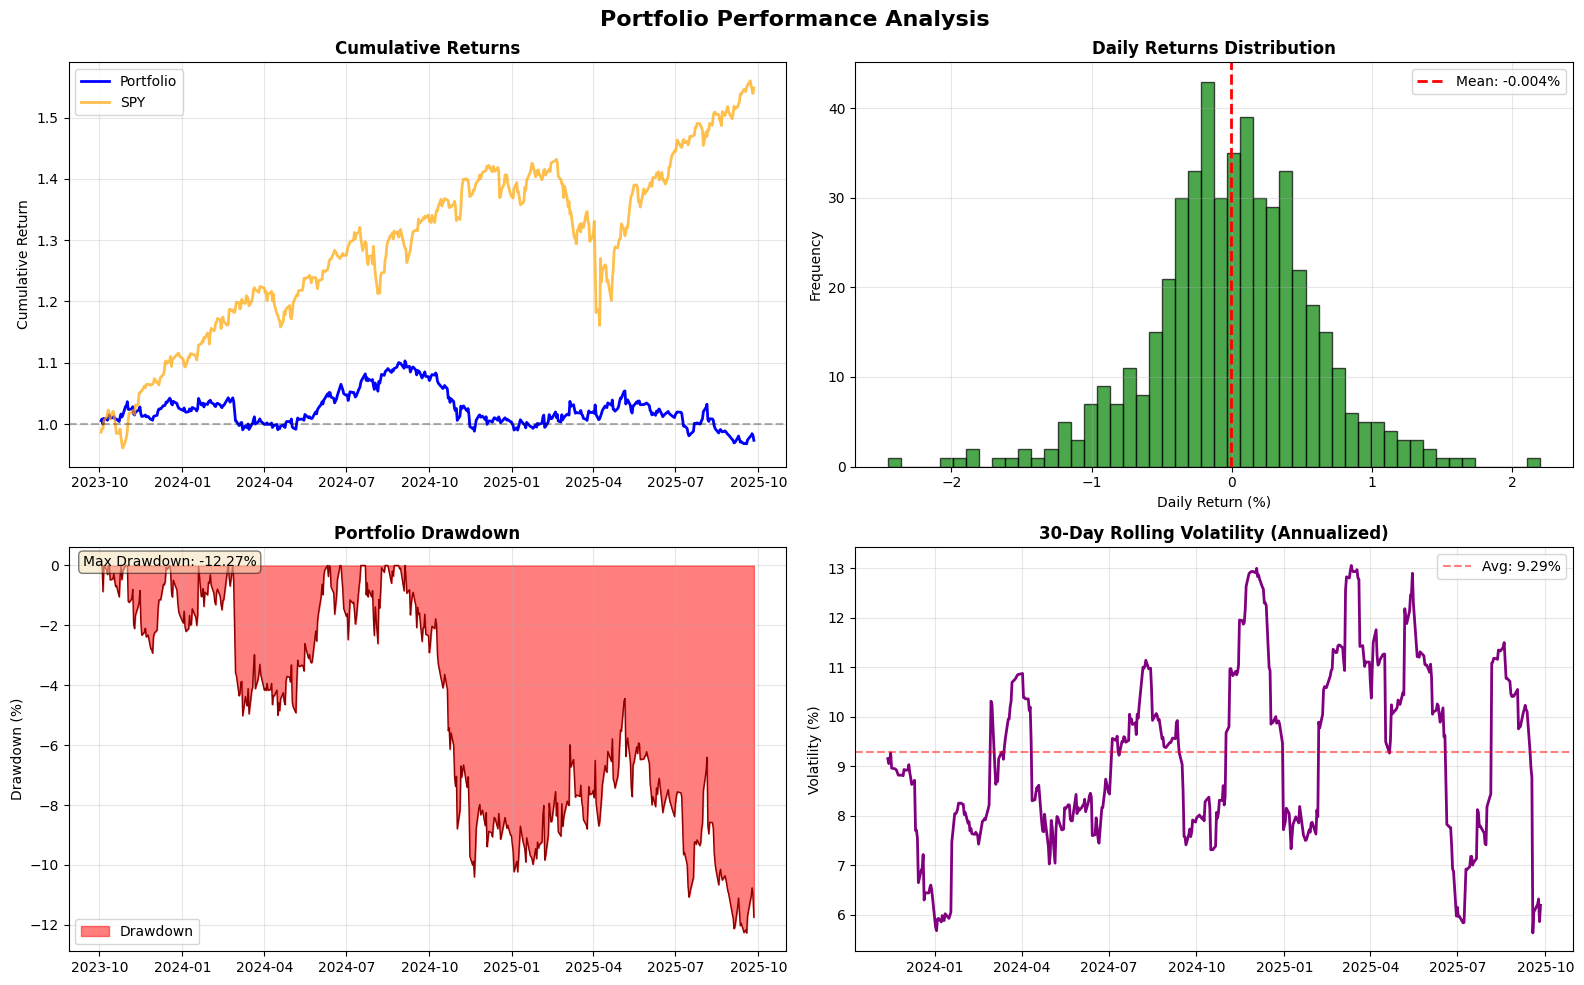

In [45]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance Analysis', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs SPY
ax1 = axes[0, 0]
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()
ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Portfolio')

if "SPY" in ticker_closes:
    spy_cumulative = (1 + spy_returns).cumprod()
    aligned_spy = spy_cumulative.reindex(portfolio_cumulative.index).ffill()
    ax1.plot(portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution
ax2 = axes[0, 1]
ax2.hist(portfolio_daily_returns.dropna() * 100, bins=50, alpha=0.7, 
         color='green', edgecolor='black')
ax2.axvline(portfolio_daily_returns.mean() * 100, color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {portfolio_daily_returns.mean()*100:.3f}%')
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart
ax3 = axes[1, 0]
running_max = portfolio_cumulative.cummax()
drawdown = (portfolio_cumulative / running_max - 1.0) * 100
ax3.fill_between(drawdown.index, drawdown.values, 0, 
                  alpha=0.5, color='red', label='Drawdown')
ax3.plot(drawdown.index, drawdown.values, linewidth=1, color='darkred')
ax3.set_title('Portfolio Drawdown', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
ax3.legend()
max_dd = drawdown.min()
ax3.text(0.02, 0.98, f'Max Drawdown: {max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day)
ax4 = axes[1, 1]
rolling_vol = portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100
ax4.plot(rolling_vol.index, rolling_vol.values, linewidth=2, color='purple')
ax4.axhline(y=annual_volatility * 100, color='red', linestyle='--', 
            alpha=0.5, label=f'Avg: {annual_volatility*100:.2f}%')
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


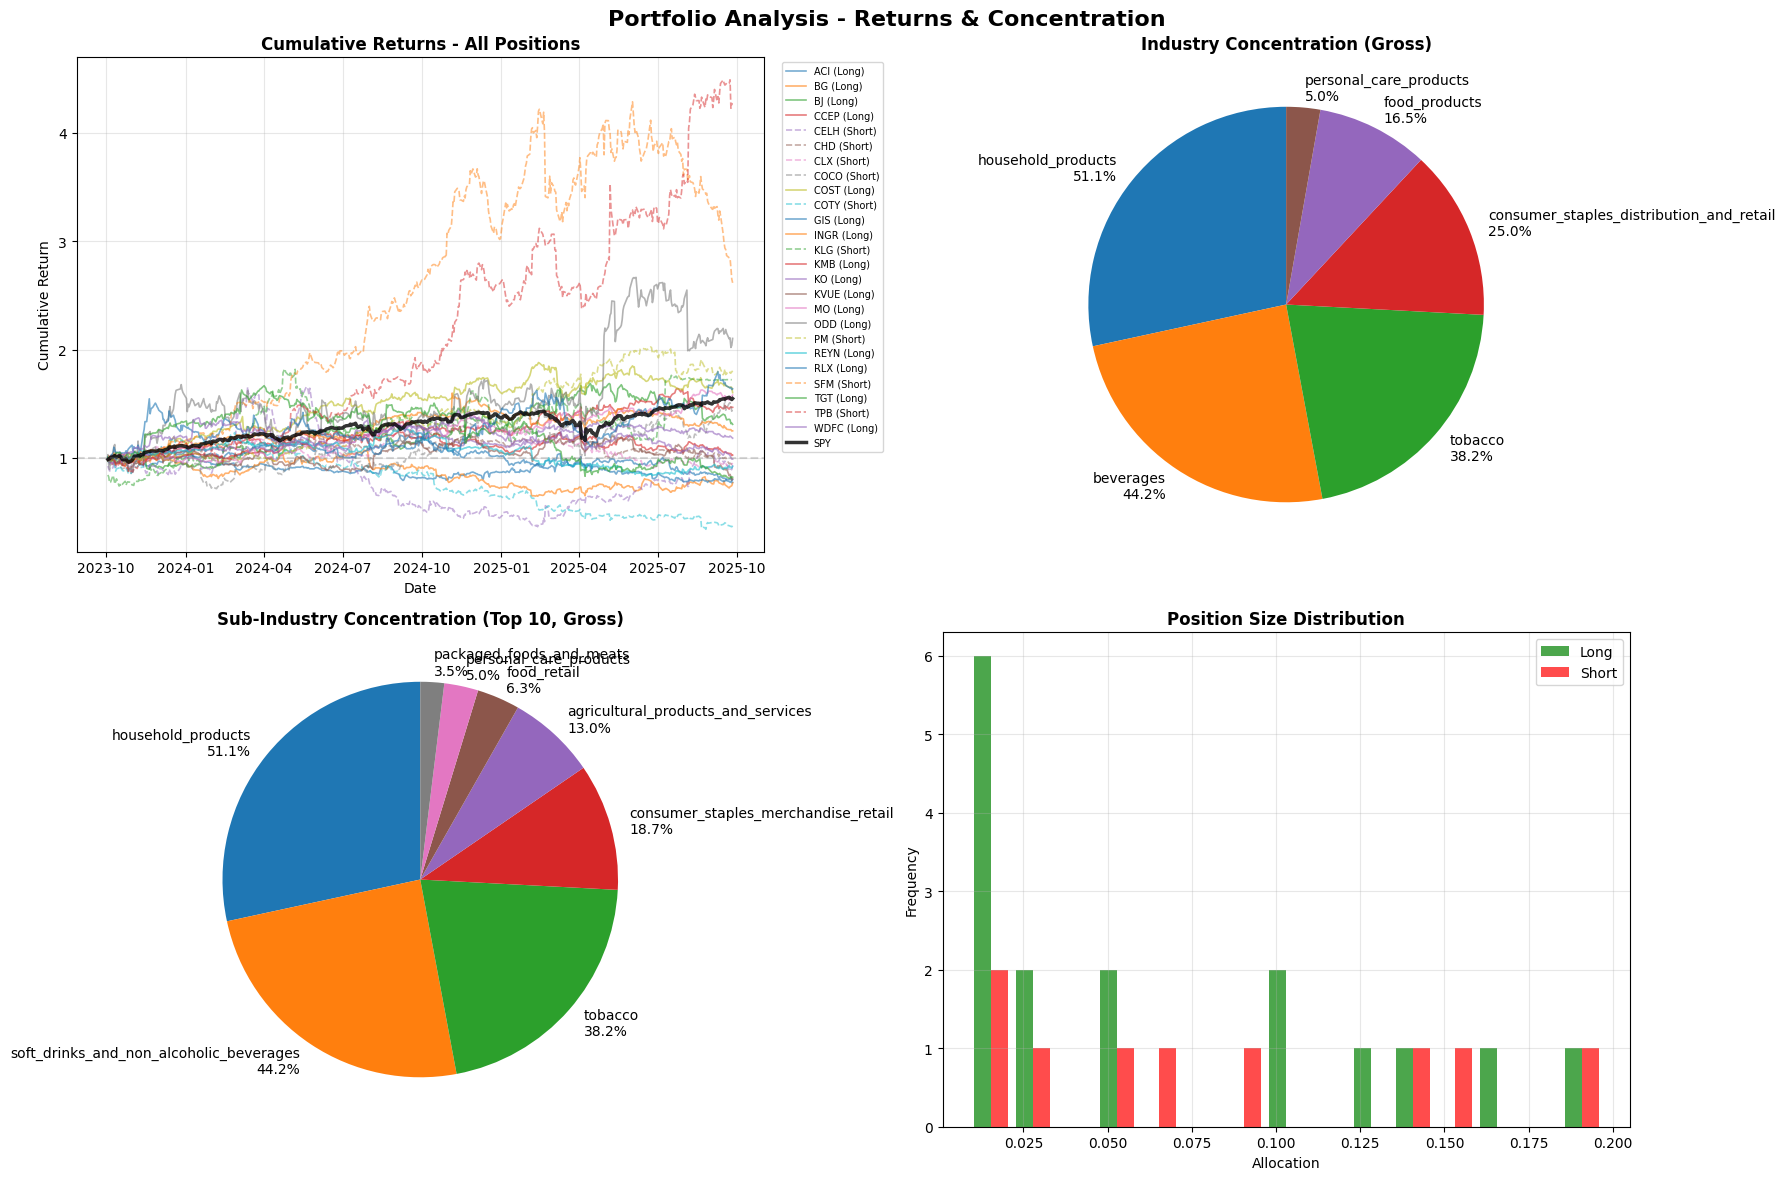

In [43]:
industry_data = {}
sub_industry_data = {}

with MarketSession() as session:
    for ticker in weights.keys():
        ticker_obj = session.query(Ticker).filter(Ticker.ticker == ticker.upper()).first()
        if ticker_obj:
            industry_data[ticker] = ticker_obj.industry
            sub_industry_data[ticker] = ticker_obj.sub_industry

# Calculate concentration by industry and sub-industry
industry_concentration = {}
sub_industry_concentration = {}

for ticker, allocation in weights.items():
    abs_allocation = abs(allocation)
    
    industry = industry_data.get(ticker, 'Unknown')
    if industry:
        industry_concentration[industry] = industry_concentration.get(industry, 0) + abs_allocation
    
    sub_industry = sub_industry_data.get(ticker, 'Unknown')
    if sub_industry:
        sub_industry_concentration[sub_industry] = sub_industry_concentration.get(sub_industry, 0) + abs_allocation

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Portfolio Analysis - Returns & Concentration', fontsize=16, fontweight='bold')

# 1. Cumulative returns of all positions
ax1 = axes[0, 0]
for ticker in sorted(weights.keys()):
    if ticker in ticker_price_returns:
        cumulative_returns = (1 + ticker_price_returns[ticker]).cumprod()
        position_type = portfolio[ticker]['position']
        
        if position_type.lower() == 'short':
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    linestyle='--', alpha=0.5, linewidth=1.2, label=f"{ticker} (Short)")
        else:
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    alpha=0.6, linewidth=1.2, label=f"{ticker} (Long)")

if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    spy_cumulative = (1 + spy_returns).cumprod()
    ax1.plot(spy_cumulative.index, spy_cumulative.values, 
            linewidth=2.5, color='black', label='SPY', alpha=0.8)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Returns - All Positions', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax1.grid(True, alpha=0.3)

# 2. Industry concentration pie chart
ax2 = axes[0, 1]
if industry_concentration:
    labels = [f"{k}\n{v:.1%}" for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    sizes = [v for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    ax2.pie(sizes, labels=labels, autopct='', startangle=90)
    ax2.set_title('Industry Concentration (Gross)', fontweight='bold')

# 3. Sub-industry concentration pie chart
ax3 = axes[1, 0]
if sub_industry_concentration:
    # Limit to top 10 for readability
    sorted_sub = sorted(sub_industry_concentration.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = [f"{k}\n{v:.1%}" for k, v in sorted_sub]
    sizes = [v for k, v in sorted_sub]
    ax3.pie(sizes, labels=labels, autopct='', startangle=90)
    ax3.set_title('Sub-Industry Concentration (Top 10, Gross)', fontweight='bold')

# 4. Position size distribution
ax4 = axes[1, 1]
long_weights = [v for v in weights.values() if v > 0]
short_weights = [abs(v) for v in weights.values() if v < 0]
ax4.hist([long_weights, short_weights], bins=15, label=['Long', 'Short'], alpha=0.7, color=['green', 'red'])
ax4.set_title('Position Size Distribution', fontweight='bold')
ax4.set_xlabel('Allocation')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


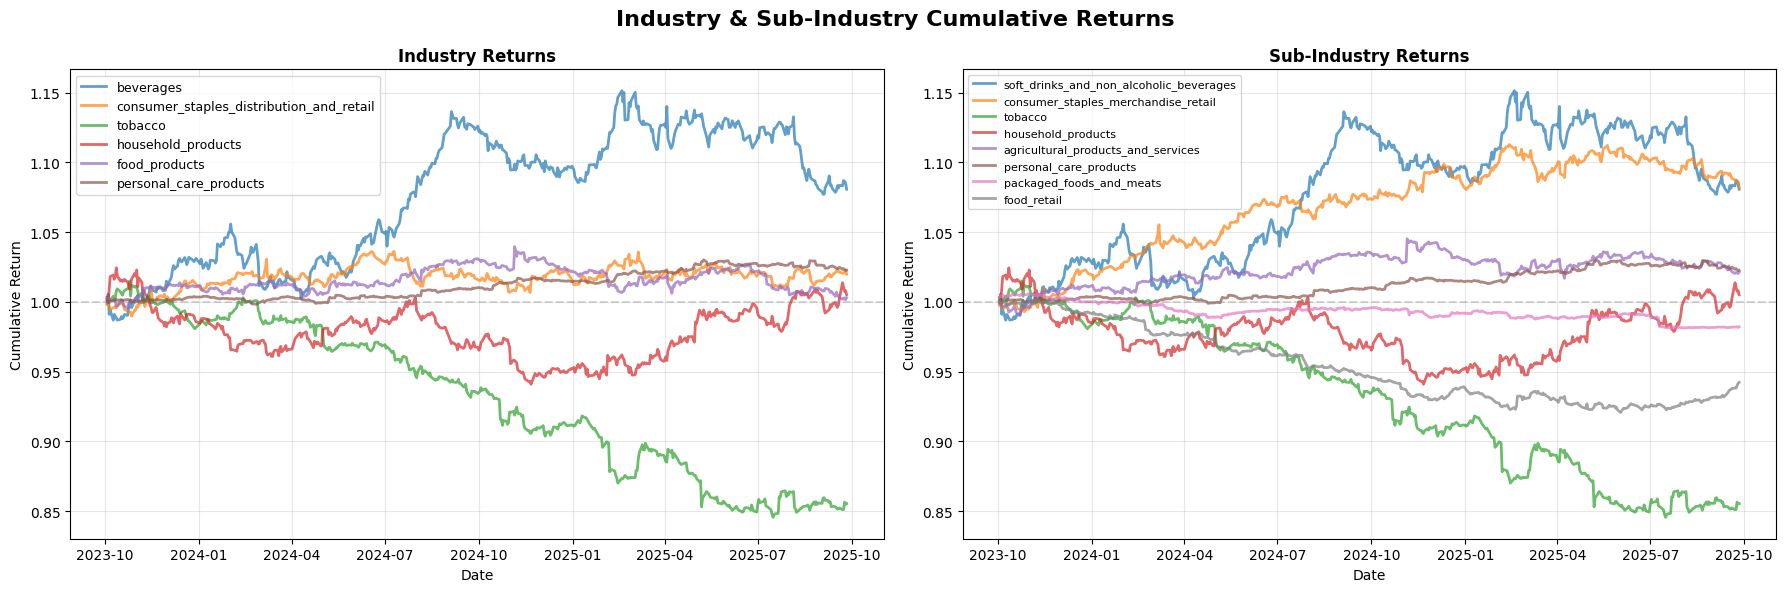

In [44]:
# Calculate industry and sub-industry level returns
# Group tickers by industry
industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        industry = industry_data.get(ticker)
        if industry:
            if industry not in industry_groups:
                industry_groups[industry] = {}
            industry_groups[industry][ticker] = allocation

# Group tickers by sub-industry
sub_industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        sub_industry = sub_industry_data.get(ticker)
        if sub_industry:
            if sub_industry not in sub_industry_groups:
                sub_industry_groups[sub_industry] = {}
            sub_industry_groups[sub_industry][ticker] = allocation

# Calculate industry-level returns
industry_returns = {}
for industry, tickers_weights in industry_groups.items():
    industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        industry_ticker_returns,
        tickers_weights,
        dropna=False,
        renormalize_each_day=True,
        normalization="gross"
    )
    industry_returns[industry] = industry_daily_returns

# Calculate sub-industry-level returns
sub_industry_returns = {}
for sub_industry, tickers_weights in sub_industry_groups.items():
    sub_industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    sub_industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        sub_industry_ticker_returns,
        tickers_weights,
        dropna=False,
        renormalize_each_day=True,
        normalization="gross"
    )
    sub_industry_returns[sub_industry] = sub_industry_daily_returns

# Create two graphs
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Industry & Sub-Industry Cumulative Returns', fontsize=16, fontweight='bold')

# 1. Industry returns
ax1 = axes[0]
for industry, returns in industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax1.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=industry)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Industry Returns', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Sub-industry returns
ax2 = axes[1]
for sub_industry, returns in sub_industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax2.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=sub_industry)

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax2.set_title('Sub-Industry Returns', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
